# Week 1 solution notebook

This solution uses GDP, consumption, and investment. The FRED API is the main workflow, and the cleaned fallback files are there if the API setup fails.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
from statsmodels.tsa.filters.hp_filter import hpfilter

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 12})


## 0. Connect to FRED


In [2]:
# Insert your own key here when running locally
# fred = Fred(api_key='YOUR_KEY_HERE')


## 1. Download data from FRED


In [3]:
# Example solution once a key is inserted:
# gdp = fred.get_series('GDPC1').rename('RealGDP')
# cons = fred.get_series('PCEC96').rename('Consumption')
# inv = fred.get_series('GPDIC1').rename('Investment')
# cons_q = cons.resample('QS').mean()
# df = pd.concat([gdp, cons_q, inv], axis=1).dropna()
# df.index.name = 'date'
# df.head()


### Optional fallback files


In [4]:
gdp = (
    pd.read_excel('week01_fred_gdp.xlsx', parse_dates=['date'])
    .set_index('date')
    .rename(columns={'GDPC1': 'RealGDP'})
)

cons = (
    pd.read_excel('week01_fred_consumption.xlsx', parse_dates=['date'])
    .set_index('date')
    .rename(columns={'PCEC96': 'Consumption'})
)

inv = (
    pd.read_excel('week01_fred_investment.xlsx', parse_dates=['date'])
    .set_index('date')
    .rename(columns={'GPDIC1': 'Investment'})
)

cons_q = cons.resample('QS').mean()

df = pd.concat([gdp, cons_q, inv], axis=1).dropna()
df.index.name = 'date'
df.head()


,RealGDP,Consumption,Investment
date,,,
2007-01-01,16611.690,11183.300000,2800.037
2007-04-01,16713.314,11212.666667,2827.010
2007-07-01,16809.587,11287.433333,2794.526
2007-10-01,16915.191,11331.966667,2762.518
2008-01-01,16843.003,11316.400000,2686.998


## 2. Summary statistics


In [5]:
summary = df.agg(['mean', 'std', 'min', 'max']).T
summary


,mean,std,min,max
RealGDP,19449.620605,2376.863333,16269.145000,24065.956000
Consumption,13192.088158,1740.010388,11075.733333,16667.033333
Investment,3330.056066,718.056394,1946.867000,4547.947000


### Raw-series plot


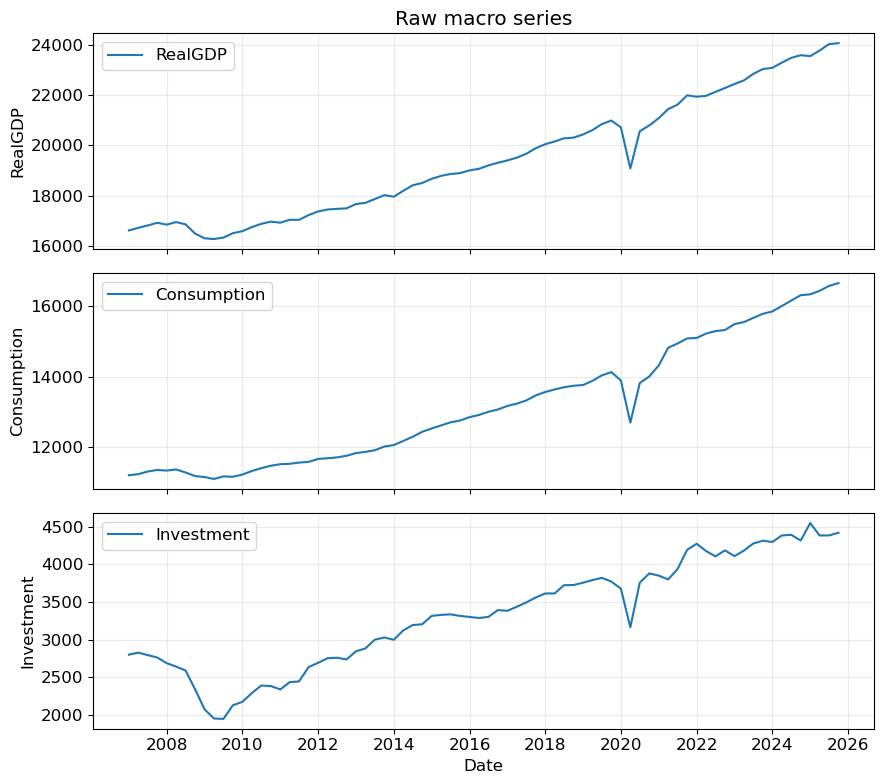

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

for ax, column in zip(axs, ['RealGDP', 'Consumption', 'Investment']):
    ax.plot(df.index, df[column], label=column)
    ax.set_ylabel(column)
    ax.legend(loc='upper left')

axs[0].set_title('Raw macro series')
axs[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


## 3. HP filter


In [7]:
for column in ['RealGDP', 'Consumption', 'Investment']:
    short = {'RealGDP': 'gdp', 'Consumption': 'cons', 'Investment': 'inv'}[column]
    df[f'log_{column}'] = np.log(df[column])
    df[f'{short}_cycle'], df[f'{short}_trend'] = hpfilter(df[f'log_{column}'], lamb=1600)


## 4. Plot trend and cycle


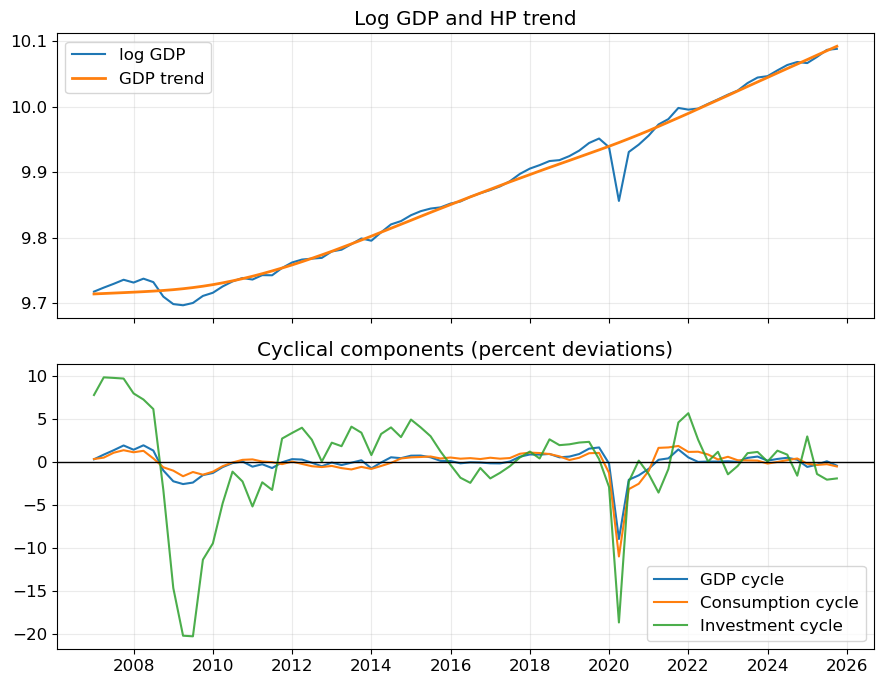

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(df.index, df['log_RealGDP'], label='log GDP')
axs[0].plot(df.index, df['gdp_trend'], label='GDP trend', linewidth=2)
axs[0].set_title('Log GDP and HP trend')
axs[0].legend()

axs[1].plot(df.index, 100 * df['gdp_cycle'], label='GDP cycle')
axs[1].plot(df.index, 100 * df['cons_cycle'], label='Consumption cycle')
axs[1].plot(df.index, 100 * df['inv_cycle'], label='Investment cycle', alpha=0.85)
axs[1].axhline(0, color='black', lw=1)
axs[1].set_title('Cyclical components (percent deviations)')
axs[1].legend()

plt.tight_layout()
plt.show()


## 5. Business-cycle statistics


In [9]:
bc_stats = pd.DataFrame({
    'volatility': [df['gdp_cycle'].std(), df['cons_cycle'].std(), df['inv_cycle'].std()],
    'corr_with_gdp_cycle': [
        df['gdp_cycle'].corr(df['gdp_cycle']),
        df['cons_cycle'].corr(df['gdp_cycle']),
        df['inv_cycle'].corr(df['gdp_cycle'])
    ]
}, index=['GDP cycle', 'Consumption cycle', 'Investment cycle'])

df_pre2020 = df.loc[:'2019-10-01'].copy()

bc_stats_pre2020 = pd.DataFrame({
    'volatility': [df_pre2020['gdp_cycle'].std(), df_pre2020['cons_cycle'].std(), df_pre2020['inv_cycle'].std()],
    'corr_with_gdp_cycle': [
        df_pre2020['gdp_cycle'].corr(df_pre2020['gdp_cycle']),
        df_pre2020['cons_cycle'].corr(df_pre2020['gdp_cycle']),
        df_pre2020['inv_cycle'].corr(df_pre2020['gdp_cycle'])
    ]
}, index=['GDP cycle', 'Consumption cycle', 'Investment cycle'])

bc_stats


,volatility,corr_with_gdp_cycle
GDP cycle,0.013762,1.000000
Consumption cycle,0.015601,0.921031
Investment cycle,0.057896,0.769891


In [10]:
bc_stats_pre2020


,volatility,corr_with_gdp_cycle
GDP cycle,0.009849,1.000000
Consumption cycle,0.007416,0.866489
Investment cycle,0.063291,0.867143


## Short Questions

Example comments:
- In the full sample, consumption can look slightly more volatile than GDP because the COVID lockdown period created an unusually large temporary drop in consumption.
- In the sample ending in 2019Q4, consumption is typically less volatile than GDP, while investment remains clearly the most volatile series.
- Consumption and investment are typically positively correlated with GDP, but investment tends to move more strongly.
- The HP filter removes the slow-moving growth trend and leaves the shorter-run fluctuations around trend.
- That is useful because business-cycle statistics should describe cyclical fluctuations rather than long-run growth.
- The lockdown period is a good reminder that special events can distort business-cycle statistics when the sample is short.
